In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

import matplotlib.pyplot as plt
import seaborn as sns
from src import *
import numpy as np


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathptmx}",  # Times Roman
    "hatch.linewidth": 3.0,
})
sns.set_context("paper",font_scale=1.5)
sns.set_palette("pastel")

# 1. Simulate population

In [2]:
### 1. initiate some params
# bounds
a0_pop_min=10
a0_pop_max=20
log_mbh_min = 6
log_mbh_max = 8

# time,rate,pop size
t=1
tR=1
popN=10000
rates = np.logspace(-1,1,50)

### 2. simulate input data as uniform
# high z pop
np.random.seed(0)
a0_pop = np.random.uniform(a0_pop_min,a0_pop_max,popN)
log_mbh_sec_pop = np.random.uniform(log_mbh_min,log_mbh_max,popN)
mbh_pop= 10**log_mbh_sec_pop
q_pop = np.random.uniform(1,100,popN)

# low z pop
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
ap = np.linspace(0,a0_pop.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obs = scp_kde(a0_pop,ap,return_func=True)
p_a0_obs_val = p_a0_obs(ap)
#predict p(af) at different rates
# p_af_preds = paf_analytic_allrates_mbhrange(p_a0_obs,a0_pop_min,a0_pop_max,
#                                             log_mbh_min, log_mbh_max,
#                                             t,af_grid=ap,
#                                             Naf=50,Na0=2000,uniform=True,
#                                             rates=np.logspace(-1,1,5))

### unit tests

/home/insepien/dftime/src/pa.py:29: RuntimeWarning: divide by zero encountered in divide
  sigma_star = mbh*t/(gamma/R)/(a0**2-a**2)/200
/home/insepien/dftime/src/pa.py:30: RuntimeWarning: invalid value encountered in log10
  exp_term = np.exp(-(np.log10(sigma_star) - 1/beta*logmbh + alpha/beta)**2 / (2*epsilon**2/beta**2))
/home/insepien/dftime/src/pa.py:31: RuntimeWarning: invalid value encountered in divide
  jacobian = 2*a/(a0**2-a**2)/np.log(10)


(200, 2000, 50)


''

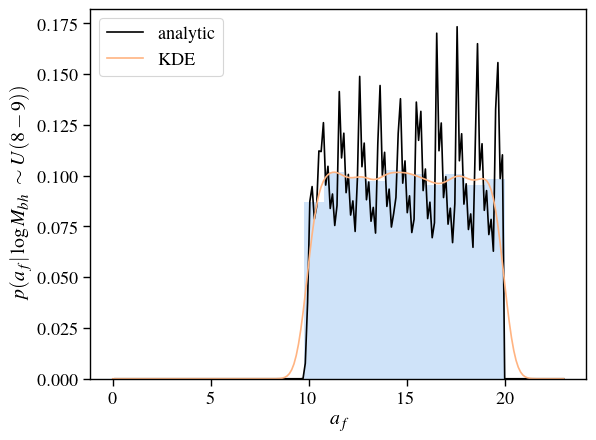

In [3]:
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)
_,paf = p_af_sigma_a0_mbhrange_unif_fast(a0_pop_min,a0_pop_max,log_mbh_min,log_mbh_max,t,tR,None)
plt.plot(_,paf,color='k',label='analytic')
plt.hist(af_pop,density=True,alpha=0.5)
# plt.plot(ap,p_a0_obs_val,c='b',alpha=0.5)
plt.plot(ap,scp_kde(af_pop,ap),label='KDE')
plt.xlabel("$a_f$")
plt.ylabel("$p({a_f}|\log{M_{bh}}~\sim U(8-9))$")
plt.legend()
;

NameError: name 'p_af_preds' is not defined

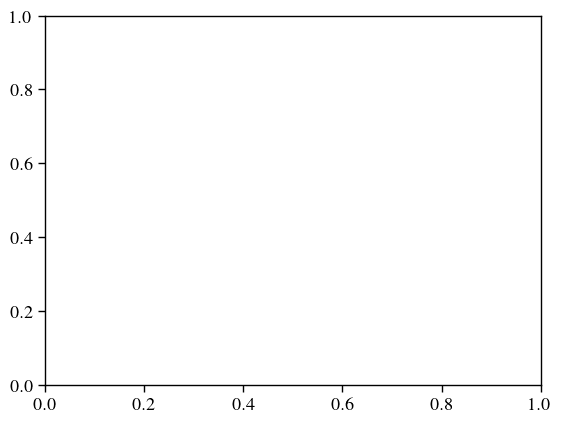

In [4]:
norm = mcolors.LogNorm(vmin=rates.min(), vmax=rates.max())
cmap = mycmap()

fig,ax = plt.subplots()

[ax.plot(ap,p,c=cmap(norm(k))) for k,p in p_af_preds.items()]
ax.plot(ap,scp_kde(af_pop,ap))
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax)

ax.plot(ap,p_a0_obs_val,label='a0 pop',c='grey',linestyle='--')
ax.plot(ap,scp_kde(af_pop,ap),label='af pop',c='k')
# ax.hist(af_pop, density=True,alpha=0.1,color='k')
ax.legend();

# 2. Sample from population

In [77]:
# 1. Define a large batch size (e.g., 10,000)
batch_size = 10000 
np.random.seed(0)
# 2. Generate arrays for all candidates at once
a = np.random.uniform(a0_pop_min, a0_pop_max, batch_size)
q = np.random.uniform(1, 100, batch_size)
z = 0.2#np.random.uniform(0.18, 0.2, batch_size)
# u = np.random.uniform(0, 0.8, batch_size)
pobs = psel(a, z, q, 0.1) #* 1/10*1/99
u = np.random.uniform(0, pobs.max(), batch_size)

# 3. Apply the mask
mask = u < pobs

# 4. Filter
accepted_a = a[mask]
accepted_q = q[mask]
accepted_pobs = pobs[mask]


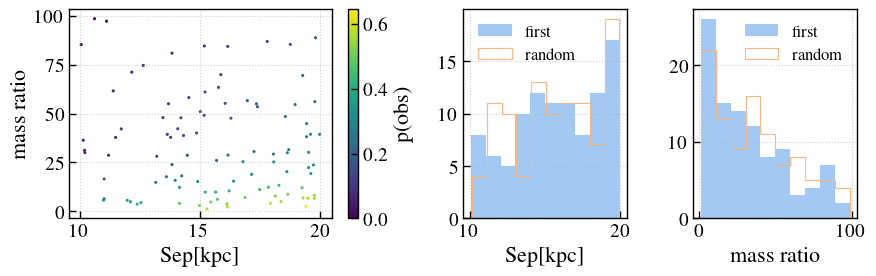

In [78]:
fig,ax = plt.subplots(1,3,figsize=(9,3),width_ratios=[2,1,1])
np.random.seed(0)
Nobs = 100
ax[0].scatter(accepted_a[:Nobs], accepted_q[:Nobs],c=accepted_pobs[:Nobs],cmap='viridis',s=2)
ax[0].set_xlabel("Sep[kpc]")
ax[0].set_ylabel("mass ratio")

ax[1].set_xlabel("Sep[kpc]")
ax[2].set_xlabel("mass ratio")

ax[1].hist(accepted_a[:Nobs],label='first')
ax[1].hist(np.random.choice(accepted_a,Nobs),histtype='step',label='random');
ax[1].legend()

ax[2].hist(accepted_q[:Nobs],label='first')
ax[2].hist(np.random.choice(accepted_q,Nobs),histtype='step',label='random');
ax[2].legend()

norm = mcolors.Normalize(vmin=0, vmax=pobs.max())
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'),ax=ax[0],label='p(obs)')

fig.tight_layout();

## 3. Correct for selection bias

In [10]:
import scipy.stats as st
from figaro.mixture import DPGMM, HDPGMM
from figaro.utils import get_priors
from tqdm import tqdm
from figaro.plot import plot_median_cr, plot_multidim

## single param DPGMM

In [29]:
Nobs = 100
a0_samp = accepted_a[:100]
q_samp = accepted_q[:100]

In [31]:
a_min = a0_pop_min-3
a_max = a0_pop_max+3
bounds = [a_min, a_max]
prior_pars = get_priors(bounds = bounds, samples = a0_samp)

mixdp = DPGMM(bounds, prior_pars = prior_pars)

ndraws = 1000
draw_1d = lambda n: mixdp.density_from_samples(a0_samp)
draws = Parallel(n_jobs=-1)(delayed(draw_1d)(n) for n in tqdm(range(ndraws)))

100%|██████████| 1000/1000 [02:01<00:00,  8.21it/s]


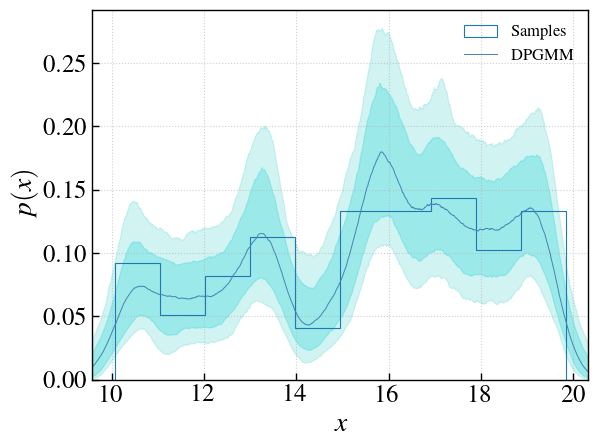

Text(0.5, 0.98, '1000 draws')

In [ ]:
fig = plot_median_cr(draws,
               samples  = a0_samp,
               save     = False,
               show     = True
               )

## 2d DPGMM

In [19]:
samples_aq = np.stack([a0_samp,q_samp],axis=1)

q_min = 0
q_max = 110

bounds = [[a_min, a_max],[q_min,q_max]]
mix_2d = DPGMM(bounds, prior_pars = get_priors(bounds, samples_aq, scale = 3))

n_draws = 100
draws_2d_func = lambda n: mix_2d.density_from_samples(samples_aq)
draws_2d = Parallel(n_jobs=-1)(delayed(draws_2d_func)(n) for n in tqdm(range(ndraws)))

100%|██████████| 500/500 [00:22<00:00, 21.87it/s]


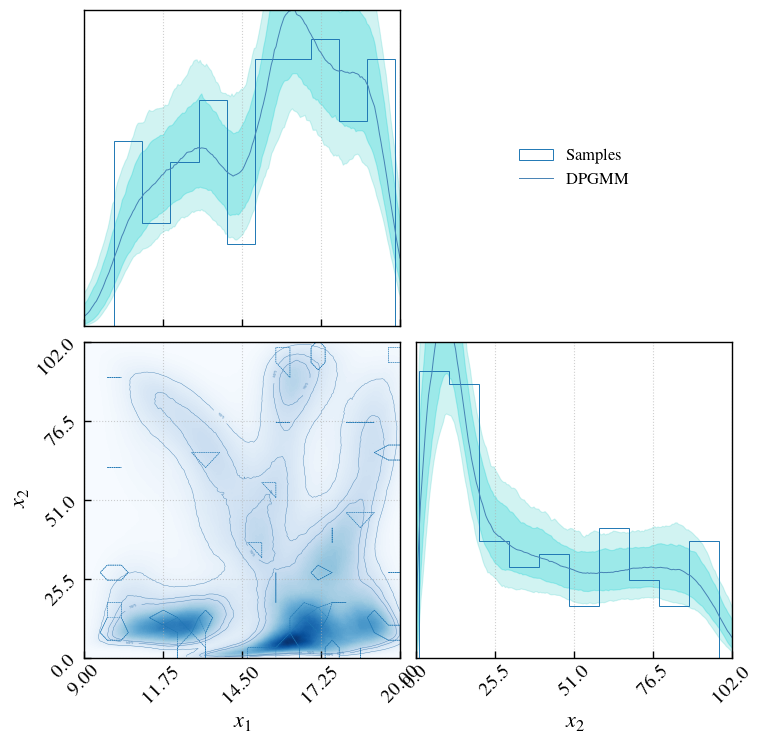

In [21]:
fig = plot_multidim(draws_2d,
                    samples = samples_aq,
                    save = False,
                    )

# single HDPGMM

In [23]:
n_post_samps = 100

single_event_posteriors = [st.norm(st.norm(a, s).rvs(), s).rvs(n_post_samps) 
                           for a, s in zip(a0_samp, np.random.uniform(1,3, size = len(a0_samp)))]

n_draws = 10
a_min = 0
a_max = 30
bounds = [[a_min, a_max]]

In [ ]:
def inner_dp1d(event):
    """get DP draws for a single observation """
    draws = []
    mix = DPGMM(bounds, prior_pars = get_priors(bounds, samples = event))
    for _ in range(n_draws):
        draws.append(mix.density_from_samples(event))
    return draws

posteriors = Parallel(n_jobs=-1)(delayed(inner_dp1d)(event) for event in tqdm(single_event_posteriors))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:00<00:00,  1.21s/it]


In [27]:
# hierarchical for bhmf
hier_mix = HDPGMM(bounds, prior_pars = get_priors(bounds, samples = single_event_posteriors, hierarchical = True))
n_draws_hier = 100
hier_draws_func = lambda n: hier_mix.density_from_samples(posteriors)
hier_draws = Parallel(n_jobs=-1)(delayed(hier_draws_func)(n) for n in tqdm(range(n_draws_hier)))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [03:21<00:00,  2.01s/it]


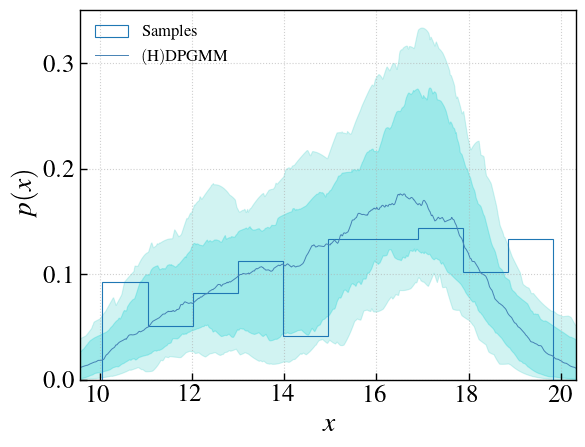

In [28]:
fig = plot_median_cr(hier_draws,
                     samples      = a0_samp,
                     show         = True,
                     hierarchical = True
                     )

## 2d HDPGMM

In [49]:
n_post_samps = 100

single_event_posteriors_a = [st.norm(st.norm(a, s).rvs(), s).rvs(n_post_samps) 
                           for a, s in zip(a0_samp, np.random.uniform(1,3, size = len(a0_samp)))]

single_event_posteriors_q = [st.norm(q, s).rvs(n_post_samps) 
                           for q, s in zip(q_samp, np.random.uniform(0.1,0.5, size = len(q_samp)))]

single_event_posteriors_aq = np.stack([single_event_posteriors_a,single_event_posteriors_q],axis=2)

In [50]:
np.min(single_event_posteriors_q),np.max(single_event_posteriors_q)

(0.12674913256525344, 98.98729643591422)

In [51]:
n_draws = 10
a_min = 0
a_max = 30
q_min = 0
q_max = 110

bounds = [[a_min, a_max],[q_min,q_max]]

# DPGMM for each event
posteriors = []
def event_dp(event):
    draws = []
    mix_2dh = DPGMM(bounds, prior_pars = get_priors(bounds, samples = event,scale=3))
    for _ in range(n_draws):
        draws.append(mix_2dh.density_from_samples(event))
    return draws

posteriors = Parallel(n_jobs=-1)(delayed(event_dp)(event) for event in tqdm(single_event_posteriors_aq))


  3%|▎         | 31/1000 [11:12<5:50:10, 21.68s/it]


In [58]:
selfunc = lambda a,q : psel(a,0.2,q,0.1)

In [61]:
# hierarchical for bhmf
hier_mix = HDPGMM(bounds, 
                  prior_pars = get_priors(bounds, samples = single_event_posteriors_aq,hierarchical = True,scale=3),
                  selection_function=selfunc
                    )
n_draws_hier = 5
hier_draws_2d = []

for _ in tqdm(range(n_draws_hier)):
    hier_draws_2d.append(hier_mix.density_from_samples(posteriors))
# hdp = lambda n: hier_mix.density_from_samples(posteriors)
# hdraws = Parallel(n_jobs=-1)(delayed(hdp)(n) for n in tqdm(range(n_draws_hier)))

TypeError: <lambda>() missing 1 required positional argument: 'q'

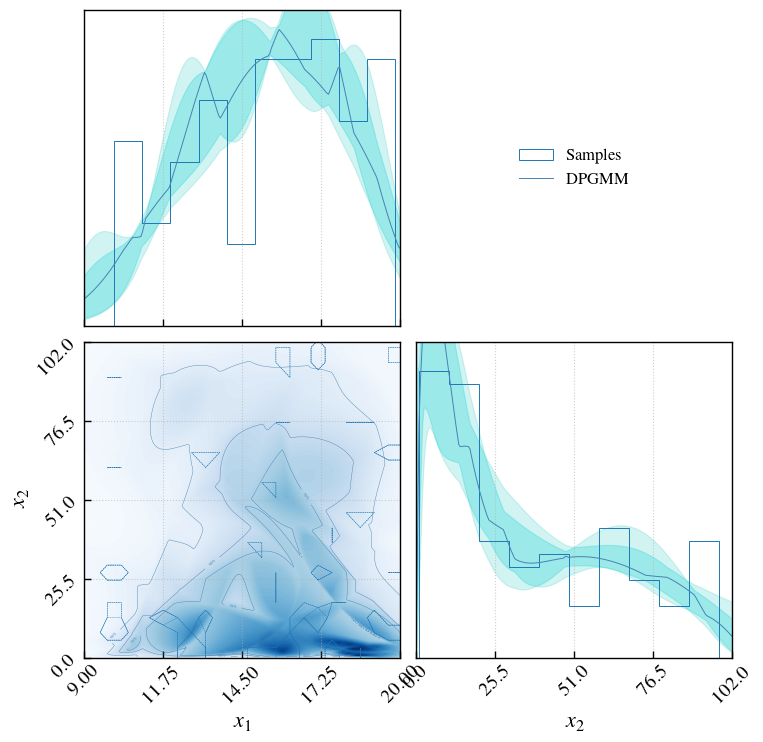

In [55]:
fig = plot_multidim(hier_draws_2d,
                    samples = samples_aq,
                    save = False,
                    )